# Validation against SST data

Contains comparision of model output and ODYSSEA satellite data of sea surface temperature by calculating metrics and plotting data.

In [1]:
%load_ext autoreload
%autoreload 2

In [55]:
from pathlib import Path
import sys

# Project root
PROJECT_ROOT = Path.cwd().parents[1]
sys.path.append(str(PROJECT_ROOT))

from modules import metrics
from modules import read_files as read
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
import glob
import h5py
import copernicusmarine


### Configuration

In [6]:
output_folder_api = Path("../../data/ODYSSEA")          # folder for downloaded file from API
output_folder_api.mkdir(parents=True, exist_ok=True)    
dir_odyssea = '../../data/ODYSSEA/odyssea.nc'           # directory to file 

dir_model = '../../data/model_output/L1/WaterProperties_1_interp.hdf5'      # directory to model output data
outdir_model = '../../data/model_output/L1//'                               # directory for converted files

### Download ODYSSEA satellite data from  API

In [ ]:
copernicusmarine.subset(
    dataset_id="IFREMER-ATL-SST-L4-NRT-OBS_FULL_TIME_SERIE",
    variables=["analysed_sst"],
    minimum_longitude=-17.67,
    maximum_longitude=-15.85,
    minimum_latitude=27.29,
    maximum_latitude=28.97,
    start_datetime="2023-01-13T00:00:00",
    end_datetime="2026-01-18T00:00:00",
    output_directory=str(output_folder_api),
    output_filename="odyssea.nc"
)

INFO - 2026-08-14T10:51:45Z - Downloading Copernicus Marine data requires a Copernicus Marine username and password, sign up for free at: https://data.marine.copernicus.eu/register


Copernicus Marine username:Copernicus Marine password:

INFO - 2026-08-14T10:52:05Z - Selected dataset version: "201904"
INFO - 2026-08-14T10:52:05Z - Selected dataset part: "default"
INFO - 2026-08-14T10:52:11Z - Starting download. Please wait...
100%|██████████| 28/28 [00:04<00:00,  5.88it/s]
INFO - 2026-08-14T10:52:16Z - Successfully downloaded to ..\..\data\ODYSSEA\odyssea.nc


ResponseSubset(file_path=WindowsPath('../../data/ODYSSEA/odyssea.nc'), output_directory=WindowsPath('../../data/ODYSSEA'), filename='odyssea.nc', file_size=16.458877862595422, data_transfer_size=166.21630534351144, variables=['analysed_sst'], coordinates_extent=[GeographicalExtent(minimum=-17.670000076293945, maximum=-15.850000381469727, unit='degrees_east', coordinate_id='longitude'), GeographicalExtent(minimum=27.290000915527344, maximum=28.969999313354492, unit='degrees_north', coordinate_id='latitude'), TimeExtent(minimum='2023-01-13T00:00:00+00:00', maximum='2026-01-18T00:00:00+00:00', unit='iso8601', coordinate_id='time')], status='000', message='The request was successful.', file_status='DOWNLOADED')

### Read data and convert model output files to netcdf

In [7]:
# read satellite data
ds_odyssea = xr.open_dataset(dir_odyssea)
ds_odyssea['sst'] = ds_odyssea['analysed_sst'] - 273.15  # convert to celcius degrees
ds_odyssea

<xarray.Dataset> Size: 138MB
Dimensions:       (time: 1102, latitude: 85, longitude: 92)
Coordinates:
  * time          (time) datetime64[ns] 9kB 2023-01-13 2023-01-14 ... 2026-01-18
  * latitude      (latitude) float32 340B 27.29 27.31 27.33 ... 28.95 28.97
  * longitude     (longitude) float32 368B -17.67 -17.65 ... -15.87 -15.85
Data variables:
    analysed_sst  (time, latitude, longitude) float64 69MB 294.9 294.9 ... 292.9
    sst           (time, latitude, longitude) float64 69MB 21.8 21.78 ... 19.72
Attributes:
    Conventions:               CF-1.7, ACDD-1.3, ISO 8601
    contact:                   emmanuelle.autret@ifremer.fr;jfpiolle@ifremer.fr
    source:                    Odyssea L4 processor
    references:                Product User Manual for L4 Odyssea Product ove...
    institution:               Institut Francais de Recherche pour l'Exploita...
    history:                   Optimally interpolated SST originally produced...
    title:                     ODYSSEA North-East Atlantic Sea Surface Temper...
    copernicusmarine_version:  2.0.1

In [15]:
# read and convert model output files
t, dates = read.MOHIDHdf5toNetcdf(dir_model, outdir=outdir_model)

# concat files with time

files = sorted(glob.glob('../../data/model_output/L1/WaterProperties_*.nc'))
datasets = [xr.open_dataset(f) for f in files]

# Stack them along a 'time' dimension
ds_model = xr.concat(datasets, dim='time')

# Close the underlying file handles now that data is in memory
for d in datasets:
    d.close()

# assign coordinate according to dates
with h5py.File(dir_model, 'r') as f:
    time_keys = sorted(f['Time'].keys())
    real_dates = []
    for k in time_keys:
        arr = f['Time'][k][:].ravel().astype(float)  
        y, m, d, H, M, S = arr[:6]
        real_dates.append(pd.Timestamp(int(y), int(m), int(d),
                                       int(H), int(M), int(round(S))))

ds_model = ds_model.assign_coords(time=('time', real_dates))

# remove fill values
ds_model = ds_model.where(ds_model.temperature > 0, drop=True)

# average to daily
ds_model = ds_model.resample(time='1D').mean() 

# rename coordinates
ds_model = ds_model.rename({'lat':'latitude'})
ds_model = ds_model.rename({'lon':'longitude'})

# interpolate model output to satellite data
ds_model = ds_model.interp(latitude=ds_odyssea.latitude, longitude=ds_odyssea.longitude)
ds_model

<xarray.Dataset> Size: 376kB
Dimensions:      (time: 6, latitude: 85, longitude: 92)
Coordinates:
  * time         (time) datetime64[us] 48B 2023-01-13 2023-01-14 ... 2023-01-18
  * latitude     (latitude) float32 340B 27.29 27.31 27.33 ... 28.93 28.95 28.97
  * longitude    (longitude) float32 368B -17.67 -17.65 -17.63 ... -15.87 -15.85
Data variables:
    temperature  (time, latitude, longitude) float32 188kB nan nan ... nan nan
    Bathymetry   (time, latitude, longitude) float32 188kB nan nan ... nan nan

### Compare

In [65]:
# Calculate metrics
temp = ds_model["temperature"]
sst = ds_odyssea["sst"]

# Keep only locations where both datasets have valid values
valid = temp.notnull() & sst.notnull()
temp_valid = temp.where(valid, drop=True)
sst_valid = sst.where(valid, drop=True)

rmse = metrics.rmse(temp_valid, sst_valid).mean()
bias = metrics.bias(temp_valid, sst_valid).mean()

# Flatten both DataArrays into 1D arrays
a = temp_valid.values.flatten()
b = sst_valid.values.flatten()

# Keep only valid paired values
mask = np.isfinite(a) & np.isfinite(b)

a = a[mask]
b = b[mask]

# Pearson correlation
pearson_value = metrics.pearson_r(a,b)

print('RMSE:', rmse.item())
print('BIAS:', bias.item())
print("pearson_correlation:", pearson_value)

RMSE: 0.7846657476294314
BIAS: -0.654357392289027
pearson_correlation: 0.1353144159866089


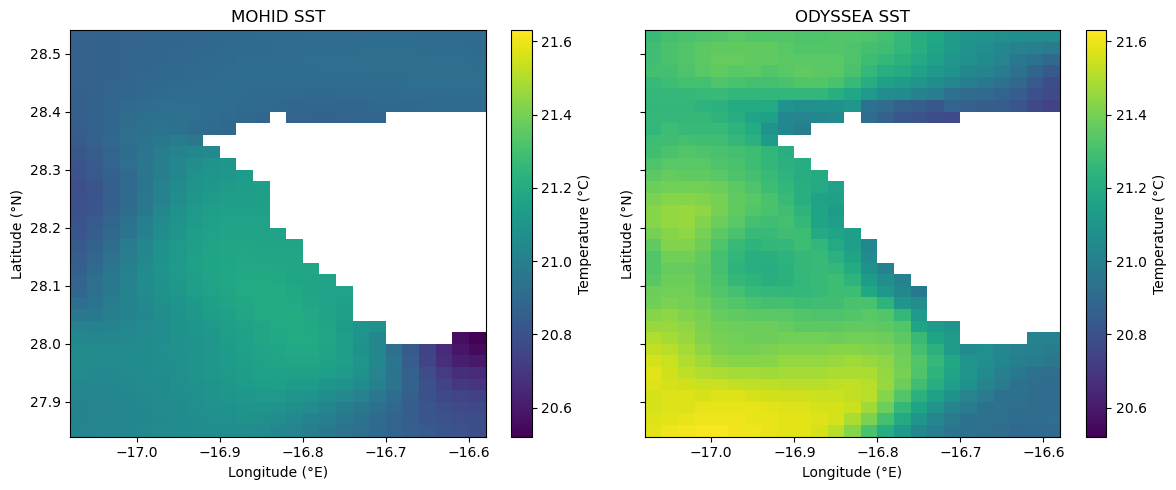

In [64]:
# visualize data
day = 2
index = day - 1

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)

# make sure color limits are same
vmin = min(
    temp_valid.isel(time=index).min().item(),
    sst_valid.isel(time=index).where(valid).min().item()
)
vmax = max(
    temp_valid.isel(time=index).where(valid).max().item(),
    sst_valid.isel(time=index).where(valid).max().item()
)


temp_valid.isel(time=index).plot(
    ax=axes[0],
   vmin=vmin,
   vmax=vmax,
    cbar_kwargs={'label': 'Temperature (°C)'}
)
axes[0].set_title("MOHID SST")


sst_valid.isel(time=index).plot(
    ax=axes[1],
    vmin=vmin,
    vmax=vmax,
    cbar_kwargs={'label': 'Temperature (°C)'}
)
axes[1].set_title("ODYSSEA SST")

# Common axis settings
for ax in axes:
    ax.set_xlim(-17.08, -16.58)
    ax.set_ylim(27.84, 28.54)
    ax.set_xlabel("Longitude (°E)")
    ax.set_ylabel("Latitude (°N)")


plt.tight_layout()
plt.show()